In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.2 MB/s eta 0:00:00


In [2]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import optuna
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment']).dropna()
df = df.drop(columns=['Unnamed: 0'])
df.head()

,clean_comment,category
0,family mormon have never tried explain them th...,2
1,buddhism has very much lot compatible with chr...,2
2,seriously don say thing first all they won get...,0
3,what you have learned yours and only yours wha...,1
4,for your own benefit you may want read living ...,2


In [4]:
ngram_range = (1, 3)
max_features = 400

X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])
vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_vec, y_train = smote.fit_resample(X_train_vec, y_train)

In [5]:
def objective(trial):

  params = {
      "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
      "max_depth": trial.suggest_int("max_depth", 3, 12),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
      "gamma": trial.suggest_float("gamma", 0, 5),
      "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
      "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
      "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
      "random_state": 42,
      "eval_metric": "logloss"
  }

  model = XGBClassifier(**params)

  score = cross_val_score(
      model,
      X_train_vec,
      y_train,
      cv=3,
      scoring="accuracy",
      n_jobs=-1
  ).mean()

  return score

In [6]:
def xg_boost_tuning(X_train, y_train, n_trials=50):
  print(X_train.shape)
  print(len(y_train))
  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=n_trials)

  print("Best Score:", study.best_value)
  print("Best Params:", study.best_params)

  best_model = XGBClassifier(
      **study.best_params,
      random_state=42,
      eval_metric="logloss"
  )

  best_model.fit(X_train, y_train)

  return best_model, study

In [7]:
best_model, study = xg_boost_tuning(
    X_train_vec,
    y_train,
    n_trials=50
)

y_pred = best_model.predict(X_test_vec)

[I 2026-06-24 07:53:50,527] A new study created in memory with name: no-name-c7b9b0f0-420d-4b04-9838-09a844be3bac


(64107, 400)
64107


[I 2026-06-24 07:54:55,066] Trial 0 finished with value: 0.7024661893396976 and parameters: {'n_estimators': 908, 'max_depth': 5, 'learning_rate': 0.06639951765935795, 'subsample': 0.8794960386224377, 'colsample_bytree': 0.765476869858002, 'gamma': 2.6413005602114614, 'min_child_weight': 6, 'reg_alpha': 0.03787223595708845, 'reg_lambda': 1.929730780343244e-05}. Best is trial 0 with value: 0.7024661893396976.
[I 2026-06-24 07:55:25,752] Trial 1 finished with value: 0.6940739700812704 and parameters: {'n_estimators': 612, 'max_depth': 3, 'learning_rate': 0.0753794115798243, 'subsample': 0.739407874074945, 'colsample_bytree': 0.6500918747739737, 'gamma': 2.0513471592776282, 'min_child_weight': 3, 'reg_alpha': 7.831727047445904e-05, 'reg_lambda': 1.165772075961283e-07}. Best is trial 0 with value: 0.7024661893396976.
[I 2026-06-24 07:55:43,766] Trial 2 finished with value: 0.7028405634330105 and parameters: {'n_estimators': 278, 'max_depth': 10, 'learning_rate': 0.16798018735723805, 'subsa

Best Score: 0.7133074391252126
Best Params: {'n_estimators': 836, 'max_depth': 10, 'learning_rate': 0.1256404693880449, 'subsample': 0.7318445076214032, 'colsample_bytree': 0.9071567573862568, 'gamma': 0.40961503669078303, 'min_child_weight': 8, 'reg_alpha': 0.0015323739453981752, 'reg_lambda': 2.9525294221316316}


In [ ]:
print(X_train_vec.shape)
print(len(y_train))

0.7184008863447512
              precision    recall  f1-score   support

           0       0.61      0.40      0.48      2109
           1       0.66      0.83      0.73      3379
           2       0.79      0.78      0.78      5343

    accuracy                           0.72     10831
   macro avg       0.69      0.67      0.67     10831
weighted avg       0.72      0.72      0.71     10831



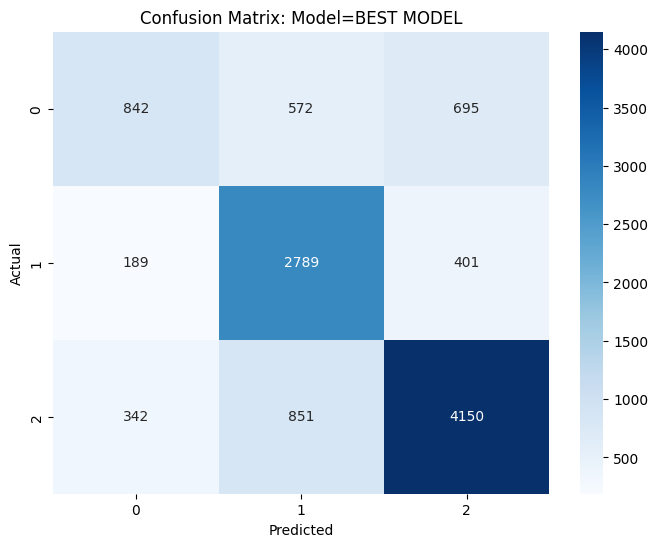

In [8]:
y_pred = best_model.predict(X_test_vec)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: Model=XGBOOST MODEL")
plt.show()

In [9]:
def objective_2(trial):
  params = {
      "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
      "num_leaves": trial.suggest_int("num_leaves", 20, 300),
      "max_depth": trial.suggest_int("max_depth", 3, 15),
      "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
      "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
      "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
      "random_state": 42,
      "verbosity": -1
  }

  model = LGBMClassifier(**params)

  score = cross_val_score(
      model,
      X_train_vec.astype(np.float32),
      y_train,
      cv=3,
      scoring="accuracy",
      n_jobs=-1
  ).mean()

  return score

In [10]:
def tune_lightgbm_optuna(X_train, y_train, n_trials=50):
  study = optuna.create_study(direction="maximize")
  study.optimize(objective_2, n_trials=n_trials)

  print("Best score:", study.best_value)
  print("Best params:", study.best_params)

  best_model = LGBMClassifier(
      **study.best_params,
      random_state=42,
      verbosity=-1
  )

  best_model.fit(X_train, y_train)

  return best_model, study

In [11]:
best_model, study = tune_lightgbm_optuna(
    X_train_vec.astype(np.float32),
    y_train,
    n_trials=30
)

[I 2026-06-24 08:44:24,801] A new study created in memory with name: no-name-25591dfb-05ea-469a-98f1-9dc179ede640
[I 2026-06-24 08:44:42,333] Trial 0 finished with value: 0.6560749996100269 and parameters: {'n_estimators': 242, 'learning_rate': 0.11047830533111792, 'num_leaves': 265, 'max_depth': 7, 'min_child_samples': 67, 'subsample': 0.6368025370675484, 'colsample_bytree': 0.7393465071096166, 'reg_alpha': 0.0002361223616876469, 'reg_lambda': 0.004270717165685268}. Best is trial 0 with value: 0.6560749996100269.
[I 2026-06-24 08:45:47,468] Trial 1 finished with value: 0.6729530316502098 and parameters: {'n_estimators': 757, 'learning_rate': 0.24570916069897972, 'num_leaves': 207, 'max_depth': 12, 'min_child_samples': 93, 'subsample': 0.6602702076022045, 'colsample_bytree': 0.8976503528465861, 'reg_alpha': 4.8414145138512575e-06, 'reg_lambda': 0.006415224436774684}. Best is trial 1 with value: 0.6729530316502098.
[I 2026-06-24 08:46:44,704] Trial 2 finished with value: 0.6553418503439

Best score: 0.6856661519022884
Best params: {'n_estimators': 404, 'learning_rate': 0.19882228724724374, 'num_leaves': 108, 'max_depth': 14, 'min_child_samples': 5, 'subsample': 0.9467816965378141, 'colsample_bytree': 0.7840709667771268, 'reg_alpha': 6.838845053923462e-06, 'reg_lambda': 0.0004731616772153601}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.6859015788015881
              precision    recall  f1-score   support

           0       0.46      0.44      0.45      2109
           1       0.68      0.72      0.70      3379
           2       0.78      0.76      0.77      5343

    accuracy                           0.69     10831
   macro avg       0.64      0.64      0.64     10831
weighted avg       0.68      0.69      0.69     10831



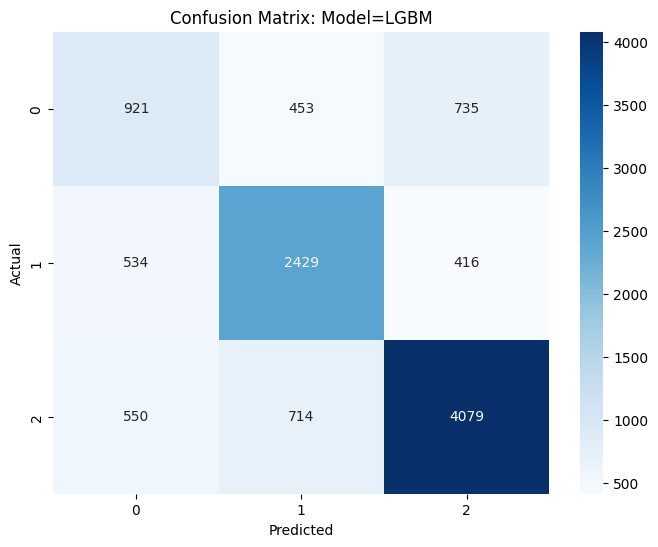

In [14]:
y_pred = best_model.predict(X_test_vec.astype(np.float32))

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: Model=LGBM")
plt.show()

Thus Selecting XGBooost with given parameters as the Model to be used

In [ ]:
def tune_logistic_regression(X_train_vec, y_train, n_trials=50):

  def objective3(trial):

    params = {
    "C": trial.suggest_float("C", 1e-1, 10, log=True),
    "penalty": trial.suggest_categorical("penalty", ["l2"]),
    "solver": trial.suggest_categorical("solver", ["liblinear", "saga", "lbfgs"]),  # saga supports all penalties
    "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    "max_iter": 1500
    }

    model = LogisticRegression(**params)

    score = cross_val_score(
        model,
        X_train_vec,
        y_train,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    return score

  study = optuna.create_study(direction="maximize")
  study.optimize(objective3, n_trials=n_trials)

  print("Best score:", study.best_value)
  print("Best params:", study.best_params)

  best_model = LogisticRegression(
      **study.best_params,
      max_iter=3000
  )

  best_model.fit(X_train_vec, y_train)

  return best_model, study

In [ ]:
best_lr, study = tune_logistic_regression(
    X_train_vec,
    y_train,
    n_trials=30
)

[I 2026-06-24 07:04:51,060] A new study created in memory with name: no-name-26e41381-ee9c-4b19-9ae0-21326b976eee
[I 2026-06-24 07:04:58,166] Trial 0 finished with value: 0.6358276007300295 and parameters: {'C': 0.1240509960707102, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.6358276007300295.
[I 2026-06-24 07:06:21,234] Trial 1 finished with value: 0.6367947338044208 and parameters: {'C': 0.11861733722941807, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6367947338044208.
[I 2026-06-24 07:08:39,702] Trial 2 finished with value: 0.6366543435194285 and parameters: {'C': 0.9508379053593088, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6367947338044208.
[I 2026-06-24 07:08:46,053] Trial 3 finished with value: 0.641115634798072 and parameters: {'C': 0.38905214923727827, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None}. Best is trial 3 wit

Best score: 0.6417083937791505
Best params: {'C': 1.5465369048811883, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None}
